In [1]:
!pip install sentencepiece
!pip install nltk rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.2/800.2 kB 64.2 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=d9e3a3ade049321f96acadea39bd99028436bb7b5bd89213cd4ada440470f4de
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
import os
import shutil
import sys
import types
import transformers.pytorch_utils

# 1. Wipe the Jina cache again
cache_path = os.path.expanduser("~/.cache/huggingface/modules/transformers_modules/jinaai")
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("🗑️ Cleared outdated Jina cache!")

# 2. The ONNX Bypass
mock_onnx = types.ModuleType('transformers.onnx')
class DummyOnnxConfig:
    pass
mock_onnx.OnnxConfig = DummyOnnxConfig
sys.modules['transformers.onnx'] = mock_onnx

# 3. The Pruneable Heads Bypass
# We inject a dummy function directly into the transformers library so Jina's import succeeds
def dummy_find_pruneable_heads_and_indices(*args, **kwargs):
    pass

transformers.pytorch_utils.find_pruneable_heads_and_indices = dummy_find_pruneable_heads_and_indices

print("🛡️ Applied the Ultimate HF API bypass patch!")

🗑️ Cleared outdated Jina cache!
🛡️ Applied the Ultimate HF API bypass patch!


## Setup, Imports, and Data Loading

In [2]:
import json

def prune_spec_for_encoder(raw_spec_dict):
    """
    Minifies the JSON string, intelligently downsamples massive data arrays, 
    and uses a recursive global sweeper to kill VLM autoregressive loops ANYWHERE in the JSON.
    """
    if not isinstance(raw_spec_dict, dict):
        return "{}"
        
    cleaned_spec = raw_spec_dict.copy()
    
    # --- [FIX 4] THE GHOST SPEC GATEKEEPER ---
    # If the chart has no series, it is mathematically dead. 
    # Reject it immediately so the description field doesn't mask it.
    if 'ser' not in cleaned_spec or not isinstance(cleaned_spec['ser'], list) or len(cleaned_spec['ser']) == 0:
        return "{}"
        
    # --- HELPER 1: Safe Float Compression ---
    def compress_val(v):
        """Rounds floats to 2 decimals, converts .0 floats to ints, leaves strings alone."""
        if isinstance(v, float):
            return int(v) if v.is_integer() else round(v, 2)
        return v

    # --- HELPER 2: The Universal Loop Killer ---
    def kill_repeating_loops(lst, max_consecutive=2, max_length=20):
        """Removes consecutive duplicates and hard-caps length at 20."""
        if not isinstance(lst, list): return lst
        cleaned_list = []
        last_item = None
        consecutive_count = 0
        
        for item in lst:
            if item == last_item:
                consecutive_count += 1
            else:
                last_item = item
                consecutive_count = 1
                
            if consecutive_count <= max_consecutive:
                cleaned_list.append(compress_val(item))
                
        return cleaned_list[:max_length]

    # --- HELPER 3: Global List Sweeper (Updated for Lists of Dicts) ---
    def sweep_for_loops(obj):
        """Recursively hunts down any list in the JSON and applies the Loop Killer."""
        if isinstance(obj, dict):
            for k, v in list(obj.items()):
                if k == 'data': 
                    continue # Leave raw data arrays to the explicit downsampler below
                if isinstance(v, list):
                    # If it's a list of primitives (strings/numbers), kill loops
                    if all(isinstance(x, (str, int, float, bool)) for x in v):
                        obj[k] = kill_repeating_loops(v)
                    # If it's a list of dicts, recurse deeper into them
                    else:
                        for item in v:
                            sweep_for_loops(item)
                elif isinstance(v, dict):
                    sweep_for_loops(v)

    # 1. Ensure structural conformity & nuke bloated relation arrays
    cleaned_spec.pop('legend', None)
    
    topo_dict = cleaned_spec.get('topo', {})
    raw_topo_type = topo_dict.get('type', '') if isinstance(topo_dict, dict) else ''
    topo_type = raw_topo_type.lower() if isinstance(raw_topo_type, str) else ''
    
    # 2. Globally sweep and kill loops in ALL fields
    sweep_for_loops(cleaned_spec)
    
    # --- [FIX 3] MASSIVE CHART TRIGGER ---
    series_list = cleaned_spec.get('ser', [])
    # is_massive_chart = len(series_list) > 3
    is_massive_chart = False
    
    # 3. Explicitly Sub-sample Series Data safely 
    for ser in series_list:
        if isinstance(ser, dict):
            
            # [FIX 2] Remove extraneous fields that slipped through
            ser.pop('ds', None)
            ser.pop('is_subsampled', None)
            ser.pop('critical_points_retained', None)
            ser.pop('y_ref', None) 
            
            # If it's a pie chart OR has too many lines, strip redundant stats/trends
            if 'pie' in topo_type or is_massive_chart:
                ser.pop('trend', None)
                ser.pop('stats', None)
            
            if 'data' in ser and isinstance(ser['data'], list):
                raw_data = ser['data']
                
                # Downsample to max 20 data points
                if len(raw_data) > 20:
                    indices = [int(i * (len(raw_data) - 1) / 19) for i in range(20)]
                    raw_data = [raw_data[i] for i in indices]
                    
                # Compress the float values inside the data array
                compressed_data = []
                for point in raw_data:
                    if isinstance(point, list):
                        compressed_data.append([compress_val(v) for v in point])
                    else:
                        compressed_data.append(compress_val(point))
                ser['data'] = compressed_data

    # Return minified JSON string
    return json.dumps(cleaned_spec, separators=(',', ':'))

In [3]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
from tqdm import tqdm

# ==========================================
# --- 1. Stage 2 Configuration ---
# ==========================================
MODEL_NAME = "jinaai/jina-embeddings-v2-base-en"
MAX_CLAIM_LEN = 256
MAX_SPEC_LEN = 5500 

# 🛡️ FIX 1: Lower physical batch size to fit gradients into VRAM
BATCH_SIZE = 2       # If it still OOMs, drop this to 1.
EFFECTIVE_BATCH_SIZE = 16 

# The accumulation steps will automatically adjust up (e.g., 16 // 2 = 8 steps)
ACCUMULATION_STEPS = EFFECTIVE_BATCH_SIZE // BATCH_SIZE

EPOCHS = 4
LEARNING_RATE = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

def load_and_prep_data(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    cleaned_data = []
    for row in data:
        raw_spec = row.get("extended_spec", {})
        if isinstance(raw_spec, dict):
            raw_spec.pop("description", None) 
            
        pruned_spec_str = prune_spec_for_encoder(raw_spec)
        if not pruned_spec_str:
            pruned_spec_str = "{}"
            
        raw_label = str(row.get("label", "")).strip().upper()
        if raw_label in ["SUPPORTED", "TRUE", "1"]:
            label = 1
        elif raw_label in ["REFUTED", "CONTRADICTED", "FALSE", "0"]:
            label = 0
        else:
            continue 
            
        cleaned_data.append({
            "claim": row.get("claim", ""),
            "description": row.get("title_description", ""), 
            "spec_str": pruned_spec_str, 
            "chart_type": row.get("chart_type", "unknown"),
            "reasoning_type": row.get("reasoning_type", ["unknown"]), 
            "label": label
        })
    return cleaned_data

print("Loading compiled datasets...")
train_data = load_and_prep_data("train_w_spec.json")
val_data = load_and_prep_data("validation_w_spec.json")
test_data = load_and_prep_data("test_1_w_spec.json") 
test2_data = load_and_prep_data("test_2_w_spec.json") 

print(f"Train samples: {len(train_data)} | Val samples: {len(val_data)} | Test samples: {len(test_data)} | Test 2 samples: {len(test2_data)}")

Using device: cuda
Loading compiled datasets...
Train samples: 7607 | Val samples: 953 | Test samples: 939 | Test 2 samples: 981


⏳ Tokenizing unique charts...

Total Unique Charts Evaluated: 1668
Max Spec Tokens: 5515
Average Spec Tokens: 579

📊 Token Length Distribution (Unique Charts):
-------------------------------------------------------
        < 512 tokens:  1029 charts (61.7%)
   512 - 1024 tokens:   413 charts (24.8%)
  1024 - 2048 tokens:   197 charts (11.8%)
  2048 - 4096 tokens:    25 charts (1.5%)
       > 4096 tokens:     4 charts (0.2%)


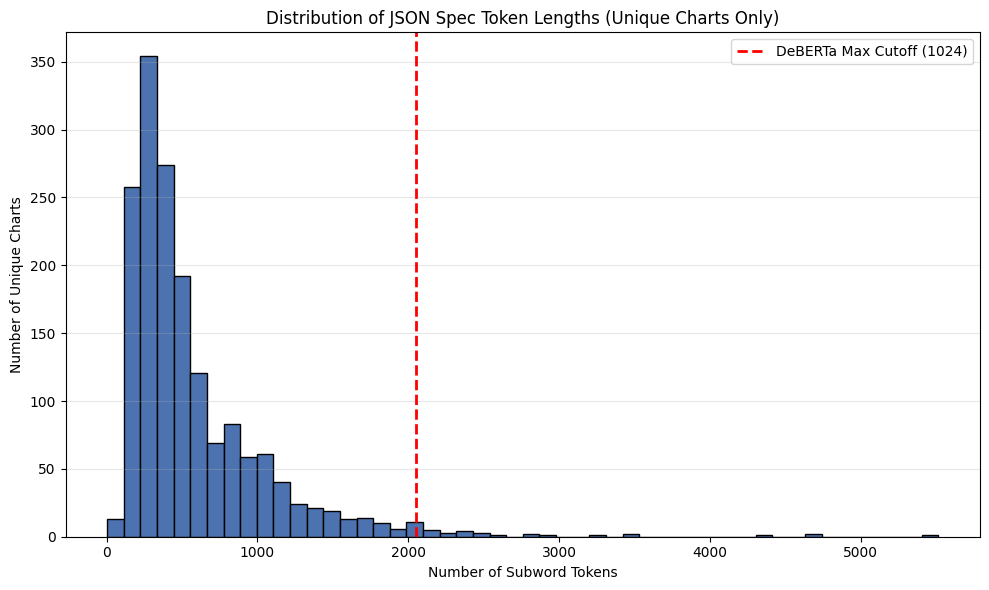

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v2-base-en")

unique_lengths = []
seen_specs = set()

print("⏳ Tokenizing unique charts...")
all_data = train_data + val_data + test_data + test2_data

# Filter for unique charts and calculate lengths
for item in all_data:
    spec = item["spec_str"]
    if spec not in seen_specs:
        seen_specs.add(spec)
        tokens = tokenizer.encode(spec) 
        unique_lengths.append(len(tokens))

print(f"\nTotal Unique Charts Evaluated: {len(unique_lengths)}")
print(f"Max Spec Tokens: {max(unique_lengths)}")
print(f"Average Spec Tokens: {sum(unique_lengths)/len(unique_lengths):.0f}\n")

# 1. Mathematical Breakdown
bins = [0, 512, 1024, 2048, 4096, 10000]
labels = ["< 512 tokens", "512 - 1024 tokens", "1024 - 2048 tokens", "2048 - 4096 tokens", "> 4096 tokens"]

hist, _ = np.histogram(unique_lengths, bins=bins)

print("📊 Token Length Distribution (Unique Charts):")
print("-" * 55)
for label, count in zip(labels, hist):
    percentage = (count / len(unique_lengths)) * 100
    print(f"{label:>20}: {count:>5} charts ({percentage:.1f}%)")

# 2. Visual Histogram
plt.figure(figsize=(10, 6))
plt.hist(unique_lengths, bins=50, color='#4C72B0', edgecolor='black')

plt.axvline(2048, color='red', linestyle='dashed', linewidth=2, label='DeBERTa Max Cutoff (1024)')

plt.title("Distribution of JSON Spec Token Lengths (Unique Charts Only)")
plt.xlabel("Number of Subword Tokens")
plt.ylabel("Number of Unique Charts")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

⏳ Tokenizing unique charts...

Total Unique Charts Evaluated: 10480
Max claim Tokens: 1711
Average claim Tokens: 53

📊 Token Length Distribution (Unique Charts):
-------------------------------------------------------
        < 256 tokens: 10254 charts (97.8%)
             256-512:   126 charts (1.2%)
   512 - 1024 tokens:    84 charts (0.8%)
  1024 - 2048 tokens:    16 charts (0.2%)


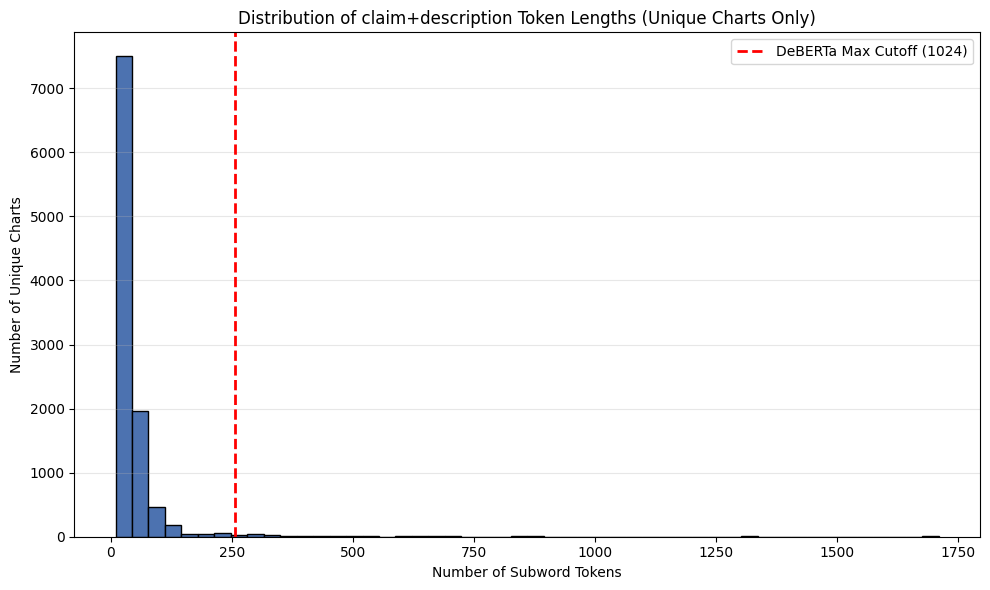

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v2-base-en")

unique_lengths = []
seen_specs = set()

print("⏳ Tokenizing unique charts...")
all_data = train_data + val_data + test_data + test2_data

# Filter for unique charts and calculate lengths
for item in all_data:
    claim = item["claim"] + item["description"]
    if spec not in seen_specs:
        seen_specs.add(claim)
        tokens = tokenizer.encode(claim) 
        unique_lengths.append(len(tokens))

print(f"\nTotal Unique Charts Evaluated: {len(unique_lengths)}")
print(f"Max claim Tokens: {max(unique_lengths)}")
print(f"Average claim Tokens: {sum(unique_lengths)/len(unique_lengths):.0f}\n")

# 1. Mathematical Breakdown
bins = [0, 256, 512, 1024, 2048]
labels = ["< 256 tokens", "256-512" ,"512 - 1024 tokens", "1024 - 2048 tokens"]

hist, _ = np.histogram(unique_lengths, bins=bins)

print("📊 Token Length Distribution (Unique Charts):")
print("-" * 55)
for label, count in zip(labels, hist):
    percentage = (count / len(unique_lengths)) * 100
    print(f"{label:>20}: {count:>5} charts ({percentage:.1f}%)")

# 2. Visual Histogram
plt.figure(figsize=(10, 6))
plt.hist(unique_lengths, bins=50, color='#4C72B0', edgecolor='black')

plt.axvline(256, color='red', linestyle='dashed', linewidth=2, label='DeBERTa Max Cutoff (1024)')

plt.title("Distribution of claim+description Token Lengths (Unique Charts Only)")
plt.xlabel("Number of Subword Tokens")
plt.ylabel("Number of Unique Charts")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import json
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load the raw dataset so we have access to the image paths
with open("train_w_spec.json", 'r', encoding='utf-8') as f:
    raw_train_data = json.load(f)

seen_images = set()
outlier_charts = []

print("🔍 Hunting for >2048 token outliers...")

for row in raw_train_data:
    img_path = row.get("local_image_path", "Unknown_Path")
    
    # Skip if we already checked this chart
    if img_path in seen_images:
        continue
    seen_images.add(img_path)
    
    # Apply your current pruner
    pruned_spec_str = prune_spec_for_encoder(row.get("extended_spec", {}))
    
    # Count the tokens
    tokens = tokenizer.encode(pruned_spec_str)
    length = len(tokens)
    
    if length > 2048:
        outlier_charts.append((img_path, length))

# Sort from largest to smallest
outlier_charts.sort(key=lambda x: x[1], reverse=True)

print(f"\n🚨 Found {len(outlier_charts)} extreme outlier charts:")
print("-" * 60)
for img, length in outlier_charts:
    # Print just the filename, ignoring the 'local_images/' folder path
    filename = img.split('/')[-1] if '/' in img else img
    print(f"[{length:^6} tokens] {filename}")

🔍 Hunting for >2048 token outliers...

🚨 Found 35 extreme outlier charts:
------------------------------------------------------------
[ 5537  tokens] Most_Popular_Wikipedia_Articles_of_the_Week_(December_23_to_29,_2018).jpg
[ 4712  tokens] On_Wikimedia.jpg
[ 4671  tokens] Evolution_of_the_expenses_of_the_Wikimedia_Foundation.jpg
[ 4400  tokens] Super_League_XIV_time_graph.jpg
[ 3512  tokens] Nobel_Prize_winners_pageview_graph_(enwiki).jpg
[ 3465  tokens] 2016_Electric_Energy_Profile_by_Fuel_Source.jpg
[ 3452  tokens] 2021_Public_opinion_on_climate_change_-_Yale_Program_on_Climate_Change_Communication.jpg
[ 3444  tokens] 20210827_Global_surface_temperature_bar_chart_-_bars_color-coded_by_El_Ni%C3%B1o_and_La_Ni%C3%B1a_intensity.jpg
[ 3230  tokens] 2017_State_electric_Generation_by_Source.jpg
[ 2893  tokens] Michiel1972edits.jpg
[ 2875  tokens] Pollsoct08apr10canada.jpg
[ 2860  tokens] En-admin-vs-article-growth.jpg
[ 2849  tokens] QCR_for_Wind_Speed_and_Pressure_from_Category_5_Hurrican

## The Dual-Stream Dataset Class

In [6]:
class ChartCheckSpecDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
        self.max_claim_len = MAX_CLAIM_LEN
        self.max_spec_len = MAX_SPEC_LEN

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        claim_text = str(item["claim"])
        desc_text = str(item.get("description", ""))
        
        claim_encoding = self.tokenizer(
            text=desc_text,
            text_pair=claim_text,
            max_length=self.max_claim_len,
            padding='max_length',
            truncation=True, # 🛡️ FIX: Changed from 'only_first' to strictly enforce the 256 limit
            return_tensors="pt"
        )
        
        spec_encoding = self.tokenizer(
            text=str(item["spec_str"]),
            max_length=self.max_spec_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        
        return {
            "claim_ids": claim_encoding["input_ids"].flatten(),
            "claim_mask": claim_encoding["attention_mask"].flatten(),
            "spec_ids": spec_encoding["input_ids"].flatten(),
            "spec_mask": spec_encoding["attention_mask"].flatten(),
            "label": torch.tensor(item["label"], dtype=torch.float),
            "chart_type": item["chart_type"],
            "reasoning_type": item["reasoning_type"]
        }

# --- CRITICAL: trust_remote_code is required for Jina ---
# --- 🛡️ FIX: Strictly isolate the Jina Tokenizer to prevent Jupyter state bleeding ---
jina_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

train_dataset = ChartCheckSpecDataset(train_data, jina_tokenizer)
val_dataset = ChartCheckSpecDataset(val_data, jina_tokenizer)
test_dataset = ChartCheckSpecDataset(test_data, jina_tokenizer)
test2_dataset = ChartCheckSpecDataset(test2_data, jina_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test2_loader = DataLoader(test2_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Model Definition

In [7]:
import sys
import torch
import torch.nn as nn
from transformers import AutoConfig, AutoModel
import transformers.modeling_utils

# 🛡️ FIX 1: STRICTLY ENFORCE bfloat16 or float32 to prevent CUDA asserts.
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    SAFE_DTYPE = torch.bfloat16
else:
    SAFE_DTYPE = torch.float32

# A dummy context manager to hijack Hugging Face's internal meta device logic
class NullContextManagers:
    def __init__(self, *args, **kwargs): pass
    def __enter__(self): pass
    def __exit__(self, *args, **kwargs): pass

class CrossAttentionVerifier(nn.Module):
    def __init__(self, model_name):
        super(CrossAttentionVerifier, self).__init__()
        
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        config.is_decoder = False
        config.add_cross_attention = False
        
        print(f"🔨 Assembling Jina-ALiBi Encoder...")
        
        original_ctx = transformers.modeling_utils.ContextManagers
        transformers.modeling_utils.ContextManagers = NullContextManagers
        try:
            self.encoder = AutoModel.from_pretrained(
                model_name,
                config=config,
                trust_remote_code=True
            )
        finally:
            transformers.modeling_utils.ContextManagers = original_ctx

        if not hasattr(self.encoder, "get_head_mask"):
            def get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
                return [None] * num_hidden_layers
            self.encoder.get_head_mask = get_head_mask.__get__(self.encoder, type(self.encoder))

        if not hasattr(self.encoder, "warn_if_padding_and_pad_id_mismatch"):
            def warn_if_padding_and_pad_id_mismatch(self, *args, **kwargs): pass
            self.encoder.warn_if_padding_and_pad_id_mismatch = warn_if_padding_and_pad_id_mismatch.__get__(self.encoder, type(self.encoder))
        
        hidden_size = self.encoder.config.hidden_size
        
        self.ln_claim = nn.LayerNorm(hidden_size)
        self.ln_spec = nn.LayerNorm(hidden_size)
        
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            batch_first=True
        )
        
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(), # <--- CRITICAL FIX: Swap ReLU for GELU
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, claim_ids, claim_mask, spec_ids, spec_mask):
        dtype = self.mlp[0].weight.dtype
        
        # 🛡️ FIX 2: THE ULTIMATE VESTIGIAL BYPASS
        # By forcing both position_ids and token_type_ids to 0, we make it 
        # mathematically impossible for the Embedding layer to index out of bounds.
        safe_claim_pos = torch.zeros_like(claim_ids, dtype=torch.long)
        safe_spec_pos = torch.zeros_like(spec_ids, dtype=torch.long)
        
        claim_outputs = self.encoder(
            input_ids=claim_ids, 
            attention_mask=claim_mask,
            position_ids=safe_claim_pos,
            token_type_ids=safe_claim_pos
        )
        spec_outputs = self.encoder(
            input_ids=spec_ids, 
            attention_mask=spec_mask,
            position_ids=safe_spec_pos,
            token_type_ids=safe_spec_pos
        )
        
        H_claim = claim_outputs.last_hidden_state  
        H_spec = spec_outputs.last_hidden_state    
        
        H_claim = self.ln_claim(H_claim)
        H_spec = self.ln_spec(H_spec)
        
        H_claim = H_claim * claim_mask.unsqueeze(-1).to(dtype)
        H_spec = H_spec * spec_mask.unsqueeze(-1).to(dtype)
        
        key_padding_mask = (spec_mask == 0)
        
        attn_output, attn_weights = self.cross_attention(
            query=H_claim,
            key=H_spec,
            value=H_spec,
            key_padding_mask=key_padding_mask,
            need_weights=True
        )
        
        input_mask_expanded = claim_mask.unsqueeze(-1).expand(attn_output.size()).to(dtype)
        sum_embeddings = torch.sum(attn_output * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-5)
        
        pooled_output = sum_embeddings / sum_mask
        logits = self.mlp(pooled_output)
        
        return logits.squeeze(-1), attn_weights

# Initialize and run a safe CPU check immediately
# 1. Move to GPU FIRST
print("Initializing model...")
model = CrossAttentionVerifier(MODEL_NAME)
if hasattr(model.encoder, "gradient_checkpointing_enable"):
    model.encoder.gradient_checkpointing_enable()
    print("✅ Gradient Checkpointing Enabled!")
model = model.to(device=DEVICE, dtype=SAFE_DTYPE)
# model.eval()

# print("🔍 Running embedded dry-run on GPU to verify patches...")
# try:
#     # 2. Grab one batch and move it to GPU for the test
#     test_batch = next(iter(train_loader))
#     with torch.no_grad():
#         model(test_batch["claim_ids"].to(DEVICE), 
#               test_batch["claim_mask"].to(DEVICE), 
#               test_batch["spec_ids"].to(DEVICE), 
#               test_batch["spec_mask"].to(DEVICE))
#     print("✅ Dry-run PASSED! The ghost matrices have been fully bypassed.")
# except Exception as e:
#     print(f"❌ Dry-run FAILED: {e}")

print(f"✅ Model successfully loaded into {DEVICE} with dtype {SAFE_DTYPE}")

Initializing model...
🔨 Assembling Jina-ALiBi Encoder...


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

You are using an old version of the checkpointing format that is deprecated (We will also silently ignore `gradient_checkpointing_kwargs` in case you passed it).Please update to the new format on your modeling file. To use the new format, you need to completely remove the definition of the method `_set_gradient_checkpointing` in your model.


✅ Gradient Checkpointing Enabled!
✅ Model successfully loaded into cuda with dtype torch.bfloat16


## The Training Loop

In [9]:
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# 1. Grab the parameters directly from the instantiated model
encoder_params = list(model.encoder.parameters())
head_params = (
    list(model.cross_attention.parameters()) + 
    list(model.mlp.parameters()) + 
    list(model.ln_claim.parameters()) + 
    list(model.ln_spec.parameters())
)

criterion = nn.BCEWithLogitsLoss()

# 2. Feed them into the optimizer
optimizer = AdamW([
    {'params': encoder_params, 'lr': 2e-5},        
    {'params': head_params, 'lr': 5e-5}      
], weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS // ACCUMULATION_STEPS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [9]:
import torch

def diagnose_data_and_model(dataloader, model):
    print("🔍 Starting Sanity Checks...")
    
    # 1. Get Model Limits
    vocab_size = model.encoder.config.vocab_size
    max_positions = model.encoder.config.max_position_embeddings
    
    print(f"-> Model Vocab Size: {vocab_size}")
    print(f"-> Model Max Position Embeddings: {max_positions}")
    print("-" * 50)
    
    model.eval() # Set to eval for testing
    
    for batch_idx, batch in enumerate(dataloader):
        c_ids = batch["claim_ids"]
        c_mask = batch["claim_mask"]
        s_ids = batch["spec_ids"]
        s_mask = batch["spec_mask"]
        labels = batch["label"]
        
        # --- TEST 1: Negative Token IDs ---
        if (c_ids < 0).any() or (s_ids < 0).any():
            print(f"❌ FATAL ERROR in Batch {batch_idx}: Negative Token IDs found!")
            return False
            
        # --- TEST 2: Token IDs Exceed Vocabulary ---
        if (c_ids >= vocab_size).any():
            max_val = c_ids.max().item()
            print(f"❌ FATAL ERROR in Batch {batch_idx}: `claim_ids` contain token {max_val}, but vocab size is only {vocab_size}.")
            print("💡 CAUSE: You are likely using a tokenizer from a different model (like DeBERTa) with Jina-BERT.")
            return False
            
        if (s_ids >= vocab_size).any():
            max_val = s_ids.max().item()
            print(f"❌ FATAL ERROR in Batch {batch_idx}: `spec_ids` contain token {max_val}, but vocab size is only {vocab_size}.")
            return False

        # --- TEST 3: Sequence Exceeds Max Position Embeddings ---
        if c_ids.shape[1] > max_positions:
            print(f"❌ FATAL ERROR in Batch {batch_idx}: `claim_ids` length ({c_ids.shape[1]}) exceeds model max position ({max_positions}).")
            return False
            
        if s_ids.shape[1] > max_positions:
            print(f"❌ FATAL ERROR in Batch {batch_idx}: `spec_ids` length ({s_ids.shape[1]}) exceeds model max position ({max_positions}).")
            return False

        # --- TEST 4: Attention Mask Shape Mismatch ---
        if c_ids.shape != c_mask.shape:
            print(f"❌ FATAL ERROR in Batch {batch_idx}: `claim_ids` shape {c_ids.shape} != `claim_mask` shape {c_mask.shape}")
            return False
            
        if s_ids.shape != s_mask.shape:
            print(f"❌ FATAL ERROR in Batch {batch_idx}: `spec_ids` shape {s_ids.shape} != `spec_mask` shape {s_mask.shape}")
            return False

        # --- TEST 5: Label Out of Bounds (For BCE Loss) ---
        # If you are using BCEWithLogitsLoss, labels must be between 0.0 and 1.0
        if (labels < 0.0).any() or (labels > 1.0).any():
            print(f"⚠️ WARNING in Batch {batch_idx}: Labels fall outside the [0, 1] range. Max: {labels.max().item()}, Min: {labels.min().item()}")
            # Not returning False here as you might be using MSE loss, but it's worth flagging.
        
        # --- TEST 6: Dry Run a Single Forward Pass (On CPU to get a readable Python stacktrace) ---
        if batch_idx == 0:
            print("✅ Tensor bounds check passed! Attempting a dry-run forward pass on CPU...")
            try:
                # Run on CPU to avoid opaque CUDA errors
                model.to('cpu')
                with torch.no_grad():
                    logits, _ = model(c_ids, c_mask, s_ids, s_mask)
                print("✅ Dry-run forward pass successful! Memory aligns perfectly.")
                
                # Put back on DEVICE
                model.to(DEVICE)
            except Exception as e:
                print(f"❌ FATAL ERROR during dry-run forward pass:\n{e}")
                return False

    print("-" * 50)
    print("🎉 ALL SANITY CHECKS PASSED! You are safe to begin training.")
    return True

# Run the diagnostic
diagnose_data_and_model(train_loader, model)

🔍 Starting Sanity Checks...
-> Model Vocab Size: 30528
-> Model Max Position Embeddings: 8192
--------------------------------------------------
✅ Tensor bounds check passed! Attempting a dry-run forward pass on CPU...
❌ FATAL ERROR during dry-run forward pass:
index out of range in self


False

In [ ]:
def evaluate(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    
    with torch.no_grad():
        for batch in dataloader:
            c_ids, c_mask = batch["claim_ids"].to(DEVICE), batch["claim_mask"].to(DEVICE)
            s_ids, s_mask = batch["spec_ids"].to(DEVICE), batch["spec_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            
            logits, _ = model(c_ids, c_mask, s_ids, s_mask)
            
            # Dynamically cast labels to match model precision
            loss = criterion(logits.to(torch.float32), labels.to(torch.float32))
            total_loss += loss.item()
            
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(dataloader), acc, f1

print(f"🚀 Initializing Stage 2 Training on {DEVICE}")
print(f"📊 Physical Batch: {BATCH_SIZE} | Effective Batch: {EFFECTIVE_BATCH_SIZE}")
best_val_f1 = 0

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    optimizer.zero_grad() 
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for step, batch in enumerate(progress_bar):
        
        c_ids, c_mask = batch["claim_ids"].to(DEVICE), batch["claim_mask"].to(DEVICE)
        s_ids, s_mask = batch["spec_ids"].to(DEVICE), batch["spec_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        
        logits, _ = model(c_ids, c_mask, s_ids, s_mask)
        loss = criterion(logits, labels.to(logits.dtype))
        
        loss = loss / ACCUMULATION_STEPS
        loss.backward()
        
        total_train_loss += (loss.item() * ACCUMULATION_STEPS)
        progress_bar.set_postfix({'loss': f"{loss.item() * ACCUMULATION_STEPS:.4f}"})
        
        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_cross_attention_verifier.pt")
        print("💾 Saved new best model!")

🚀 Initializing Stage 2 Training on cuda
📊 Physical Batch: 2 | Effective Batch: 16


Epoch 1/4:   0%|          | 0/3804 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Epoch 1/4:   4%|▍         | 153/3804 [03:04<1:13:40,  1.21s/it, loss=0.6953]

## Fine-Grained Evaluation Matrix (Amar et al.)

In [ ]:
print("\n--- FINAL EVALUATION MATRIX ---")
# Load best weights
model.load_state_dict(torch.load("best_cross_attention_verifier.pt"))
model.eval()

results_record = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Test Set"):
        c_ids, c_mask = batch["claim_ids"].to(DEVICE), batch["claim_mask"].to(DEVICE)
        s_ids, s_mask = batch["spec_ids"].to(DEVICE), batch["spec_mask"].to(DEVICE)
        labels = batch["label"].cpu().numpy()
        chart_types = batch["chart_type"]
        reasoning_types = batch["reasoning_type"]
        
        # --- FIX: Unpack the tuple ---
        logits, _ = model(c_ids, c_mask, s_ids, s_mask)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
        
        for i in range(len(preds)):
            # Handle the reasoning type array (e.g., ["Filter", "Compare"])
            r_types = reasoning_types[i]
            if isinstance(r_types, str):
                r_types = [r_types]
                
            for r_type in r_types:
                # Filter out 'unknown' cognitive tasks
                if str(r_type).strip().lower() == "unknown":
                    continue
                    
                results_record.append({
                    "chart_type": chart_types[i],
                    "reasoning_type": r_type,
                    "true_label": labels[i],
                    "prediction": preds[i]
                })

df_results = pd.DataFrame(results_record)
df_results['correct'] = (df_results['true_label'] == df_results['prediction']).astype(int)

print("\n1. Performance by Topology Variance (Chart Type)")
print("-" * 50)
topology_summary = df_results.groupby('chart_type')['correct'].agg(['mean', 'count']).rename(columns={'mean': 'Accuracy', 'count': 'Sample Size'})
topology_summary['Accuracy'] = (topology_summary['Accuracy'] * 100).round(1).astype(str) + '%'
print(topology_summary)

print("\n2. Cognitive Task Evaluation (Amar et al. Reasoning Types)")
print("-" * 50)
reasoning_summary = df_results.groupby('reasoning_type')['correct'].agg(['mean', 'count']).rename(columns={'mean': 'Accuracy', 'count': 'Sample Size'})
reasoning_summary['Accuracy'] = (reasoning_summary['Accuracy'] * 100).round(1).astype(str) + '%'
print(reasoning_summary)

## Explainability Integration Module

In [ ]:
!pip install accelerate

In [ ]:
import re
import torch
import pandas as pd
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer as CausalTokenizer

# --- Initialize the Lightweight Rationale LLM ---
print("Loading Qwen2.5-0.5B-Instruct for Explanation Generation...")
llm_model_id = "Qwen/Qwen2.5-0.5B-Instruct"
llm_tokenizer = CausalTokenizer.from_pretrained(llm_model_id)
llm_model = AutoModelForCausalLM.from_pretrained(
    llm_model_id, 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)
rationale_generator = pipeline("text-generation", model=llm_model, tokenizer=llm_tokenizer)


def extract_top_k_json_trace(spec_str, spec_tokens, attention_vector, k=3):
    """Maps high-attention subword tokens back to their parent JSON keys."""
    top_indices = torch.topk(attention_vector, k).indices.cpu().numpy()
    traces = []
    
    for idx in top_indices:
        token_text = tokenizer.decode([spec_tokens[idx]]).strip()
        context_window = spec_str[:spec_str.find(token_text) + len(token_text)]
        keys = re.findall(r'"([a-zA-Z0-9_]+)":', context_window)
        parent_key = keys[-1] if keys else "root"
        
        trace = f"spec.{parent_key} -> '{token_text}'"
        if trace not in traces:
            traces.append(trace)
            
    return traces

def generate_pipeline_output(claim, spec_str, pred_label, traces):
    """Feeds the mathematical traces into the real LLM to synthesize a rationale."""
    label_str = "SUPPORTED (TRUE)" if pred_label == 1 else "CONTRADICTED (FALSE)"
    
    atomic_verifications = [f"Premise based on {trace} heavily influenced the decision." for trace in traces]
    atomic_text = "\n".join([f"  - {av}" for av in atomic_verifications])
    
    # Prompt formatting for Qwen Instruct
    messages = [
        {"role": "system", "content": "You are an analytical assistant. You explain why a claim about a chart is true or false based strictly on the provided JSON Traces. Keep your answer to 1 or 2 concise sentences."},
        {"role": "user", "content": f"Claim: {claim}\nPredicted Label: {label_str}\nJSON Traces (High-Attention Fields):\n{atomic_text}\n\nExplain why this claim is {label_str}."}
    ]
    
    prompt = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    outputs = rationale_generator(prompt, max_new_tokens=75, temperature=0.1, do_sample=False)
    synthesized_rationale = outputs[0]["generated_text"].split("<|im_start|>assistant\n")[-1].strip()
    
    return label_str, atomic_verifications, synthesized_rationale

# --- Run the Explainability Pipeline on a Sample ---
print("\n--- RUNNING EXPLAINABILITY MODULE ---")
model.load_state_dict(torch.load("best_cross_attention_verifier.pt"))
model.eval()

sample = test_dataset[0]
c_ids, c_mask = sample["claim_ids"].unsqueeze(0).to(DEVICE), sample["claim_mask"].unsqueeze(0).to(DEVICE)
s_ids, s_mask = sample["spec_ids"].unsqueeze(0).to(DEVICE), sample["spec_mask"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits, attn_weights = model(c_ids, c_mask, s_ids, s_mask)
    pred_val = (torch.sigmoid(logits) >= 0.5).long().item()
    global_spec_attention = attn_weights[0].mean(dim=0) 

raw_spec_str = test_data[0]["spec_str"]
spec_tokens = sample["spec_ids"]

traces = extract_top_k_json_trace(raw_spec_str, spec_tokens, global_spec_attention, k=4)
label, atomics, rationale = generate_pipeline_output(test_data[0]["claim"], raw_spec_str, pred_val, traces)

print(f"CLAIM: {test_data[0]['claim']}")
print(f"PREDICTION: {label}")
print(f"JSON TRACES: {traces}")
print(f"SYNTHESIZED RATIONALE:\n{rationale}")

## The Automated Evaluation Matrix

In [ ]:
!pip install nltk rouge-score bert-score evaluate
!pip install git+https://github.com/google-research/bleurt.git

In [ ]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
from rouge_score import rouge_scorer
from bert_score import score as calc_bert_score
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import ConcatDataset

# --- 0. Initial Setup & Downloads ---
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("1️⃣ Calculating Classification Accuracy & F1 Scores...")
model.eval()

def evaluate_classification(dataloader, desc_label):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc_label):
            c_ids, c_mask = batch["claim_ids"].to(DEVICE), batch["claim_mask"].to(DEVICE)
            s_ids, s_mask = batch["spec_ids"].to(DEVICE), batch["spec_mask"].to(DEVICE)
            labels = batch["label"].cpu().numpy()
            
            logits, _ = model(c_ids, c_mask, s_ids, s_mask)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)
            
    acc = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='macro') * 100
    return acc, f1

my_test1_acc, my_test1_f1 = evaluate_classification(test_loader, "Evaluating Test 1")
my_test2_acc, my_test2_f1 = evaluate_classification(test2_loader, "Evaluating Test 2")
my_avg_acc = (my_test1_acc + my_test2_acc) / 2.0 

print(f"✅ Test 1 -> Acc: {my_test1_acc:.1f}% | F1: {my_test1_f1:.1f}")
print(f"✅ Test 2 -> Acc: {my_test2_acc:.1f}% | F1: {my_test2_f1:.1f}")
print(f"✅ Average Test Accuracy: {my_avg_acc:.1f}%\n")


print("2️⃣ Generating Synthesized Rationales (Test 1 & Test 2 Combined)...")
references = []
predictions = []

combined_test_data = test_data + test2_data
combined_test_dataset = ConcatDataset([test_dataset, test2_dataset])

with torch.no_grad():
    # Note: Slice combined_test_dataset (e.g., [:200]) if you want a faster test run
    for idx, sample in enumerate(tqdm(combined_test_dataset, desc="Extracting & Generating")):
        gt_explanation = combined_test_data[idx].get("explanation", "")
        if not gt_explanation:
            continue
            
        c_ids, c_mask = sample["claim_ids"].unsqueeze(0).to(DEVICE), sample["claim_mask"].unsqueeze(0).to(DEVICE)
        s_ids, s_mask = sample["spec_ids"].unsqueeze(0).to(DEVICE), sample["spec_mask"].unsqueeze(0).to(DEVICE)
        
        logits, attn_weights = model(c_ids, c_mask, s_ids, s_mask)
        pred_val = (torch.sigmoid(logits) >= 0.5).long().item()
        global_spec_attention = attn_weights[0].mean(dim=0)
        
        raw_spec_str = combined_test_data[idx]["spec_str"]
        traces = extract_top_k_json_trace(raw_spec_str, sample["spec_ids"], global_spec_attention, k=4)
        
        _, _, rationale = generate_pipeline_output(combined_test_data[idx]["claim"], raw_spec_str, pred_val, traces)
        
        references.append(gt_explanation)
        predictions.append(rationale)

print(f"\n3️⃣ Calculating Core NLP Metrics over {len(predictions)} samples...")

# A. BLEU & ROUGE (CPU Calculations)
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
chencherry = SmoothingFunction()

bleu_scores, rouge_scores = [], []

for ref, pred in zip(references, predictions):
    ref_tokens = word_tokenize(ref)
    pred_tokens = word_tokenize(pred)
    
    # BLEU
    bleu_scores.append(sentence_bleu([ref_tokens], pred_tokens, smoothing_function=chencherry.method1))
    # ROUGE
    rouge_scores.append(scorer.score(ref, pred)['rougeL'].fmeasure)

my_bleu = np.mean(bleu_scores) * 100
my_rouge = np.mean(rouge_scores) * 100
print(f"✔️ BLEU: {my_bleu:.1f} | ROUGE-L: {my_rouge:.1f}")

# B. BERTScore (Semantic Meaning - GPU Calculation)
print("⏳ Calculating BERTScore (measuring semantic similarity)...")
P, R, F1 = calc_bert_score(predictions, references, lang="en", rescale_with_baseline=True, verbose=False)
my_bertscore = F1.mean().item() * 100
print(f"✔️ BERTScore: {my_bertscore:.1f}")


print("\n4️⃣ Compiling the Final ChartCheck Matrix...")
# Added Test1_F1 and Test2_F1 mapped from Table 3
chartcheck_baselines = {
    "Model": [
        "DePlot-DeBERTa-class", 
        "DePlot-FlanT5-finetune-multi", 
        "MatCha-finetune-multi",
        "GPT4V (Zero-Shot)"
    ],
    "Task": ["C", "M", "M", "M"],
    "Test1_Acc": [75.0, 65.7, 59.4, 73.8],
    "Test1_F1":  [75.0, 65.7, 59.1, 73.5],
    "Test2_Acc": [72.5, 65.9, 61.1, 72.0],
    "Test2_F1":  [72.5, 65.8, 60.9, 71.3],
    "Avg_Test_Acc": [73.8, 65.8, 60.2, 72.9],
    "BLEU": ["-", 17.3, 17.1, 10.0],
    "Rouge": ["-", 46.3, 37.3, 32.3],
    "BERTScore": ["-", 91.5, 67.8, 89.1]
}

df_baselines = pd.DataFrame(chartcheck_baselines)

my_model_data = {
    "Model": ["Ext_ChartSpec+DeBERTa->Qwen"],
    "Task": ["Pipeline"],
    "Test1_Acc": [round(my_test1_acc, 1)],
    "Test1_F1":  [round(my_test1_f1, 1)],
    "Test2_Acc": [round(my_test2_acc, 1)],
    "Test2_F1":  [round(my_test2_f1, 1)],
    "Avg_Test_Acc": [round(my_avg_acc, 1)],
    "BLEU": [round(my_bleu, 1)],
    "Rouge": [round(my_rouge, 1)],
    "BERTScore": [round(my_bertscore, 1)]
}

df_ours = pd.DataFrame(my_model_data)
evaluation_matrix = pd.concat([df_baselines, df_ours], ignore_index=True)

print("\n" + "=" * 110)
print("📊 STREAMLINED BASELINE COMPARISON MATRIX")
print("=" * 110)
print(evaluation_matrix.to_string(index=False))
print("=" * 110)